### Prerequisites

In [ ]:
import anndata

import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy.stats import median_abs_deviation

import celltypist
from celltypist import models
import matplotlib.pyplot as plt

import os

import scvi
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

sc.settings.verbosity = 3
sc.logging.print_header()
sc.settings.set_figure_params(dpi=300, facecolor='white', frameon=False,  figsize=[4,4])

### Annotate data

In [ ]:
adata_epithelial = sc.read_h5ad(filename='../yourpath/3_infercnv_adata_epithelial.h5ad')
adata_epithelial

In [ ]:
cell_type = {
    '0': 'Cancer cells (basal-like)',
    '1': 'Cancer cells (classical)',
    '2': 'Cancer cells (classical)',
    '3': 'Acinar cells',
    '4': 'Acinar cells',
    '5': 'Cancer cells (exocrine-like)',
    '6': '6',
    '7': 'Cancer cells (basal-like)',
    '8': 'Cancer cells (classical)',
    '9': 'Cancer cells (basal-like)',
    '10': 'Acinar cells',
    '11': 'Acinar cells',
    '12': 'Cancer cells (basal-like)',
    '13': 'Cancer cells (classical)',
    '14': 'Islet cells',
    '15': 'Cancer cells (exocrine-like)',
    '16': 'Acinar cells',
    '17': 'Cancer cells (classical)',
    '18': 'Cancer cells (basal-like)',
    '19': 'Acinar cells',
    '20': 'Cancer cells (classical)',
    '21': 'Cancer cells (basal-like)',
    '22': 'Cancer cells (basal-like)',
    '23': 'Cancer cells (classical)',
    '24': 'Acinar cells',
    '25': 'Cancer cells (classical)',
    '26': 'Acinar cells',
}
adata_epithelial.obs['anno_epithelial'] = adata_epithelial.obs.leiden.map(cell_type)

... storing 'anno_epithelial' as categorical


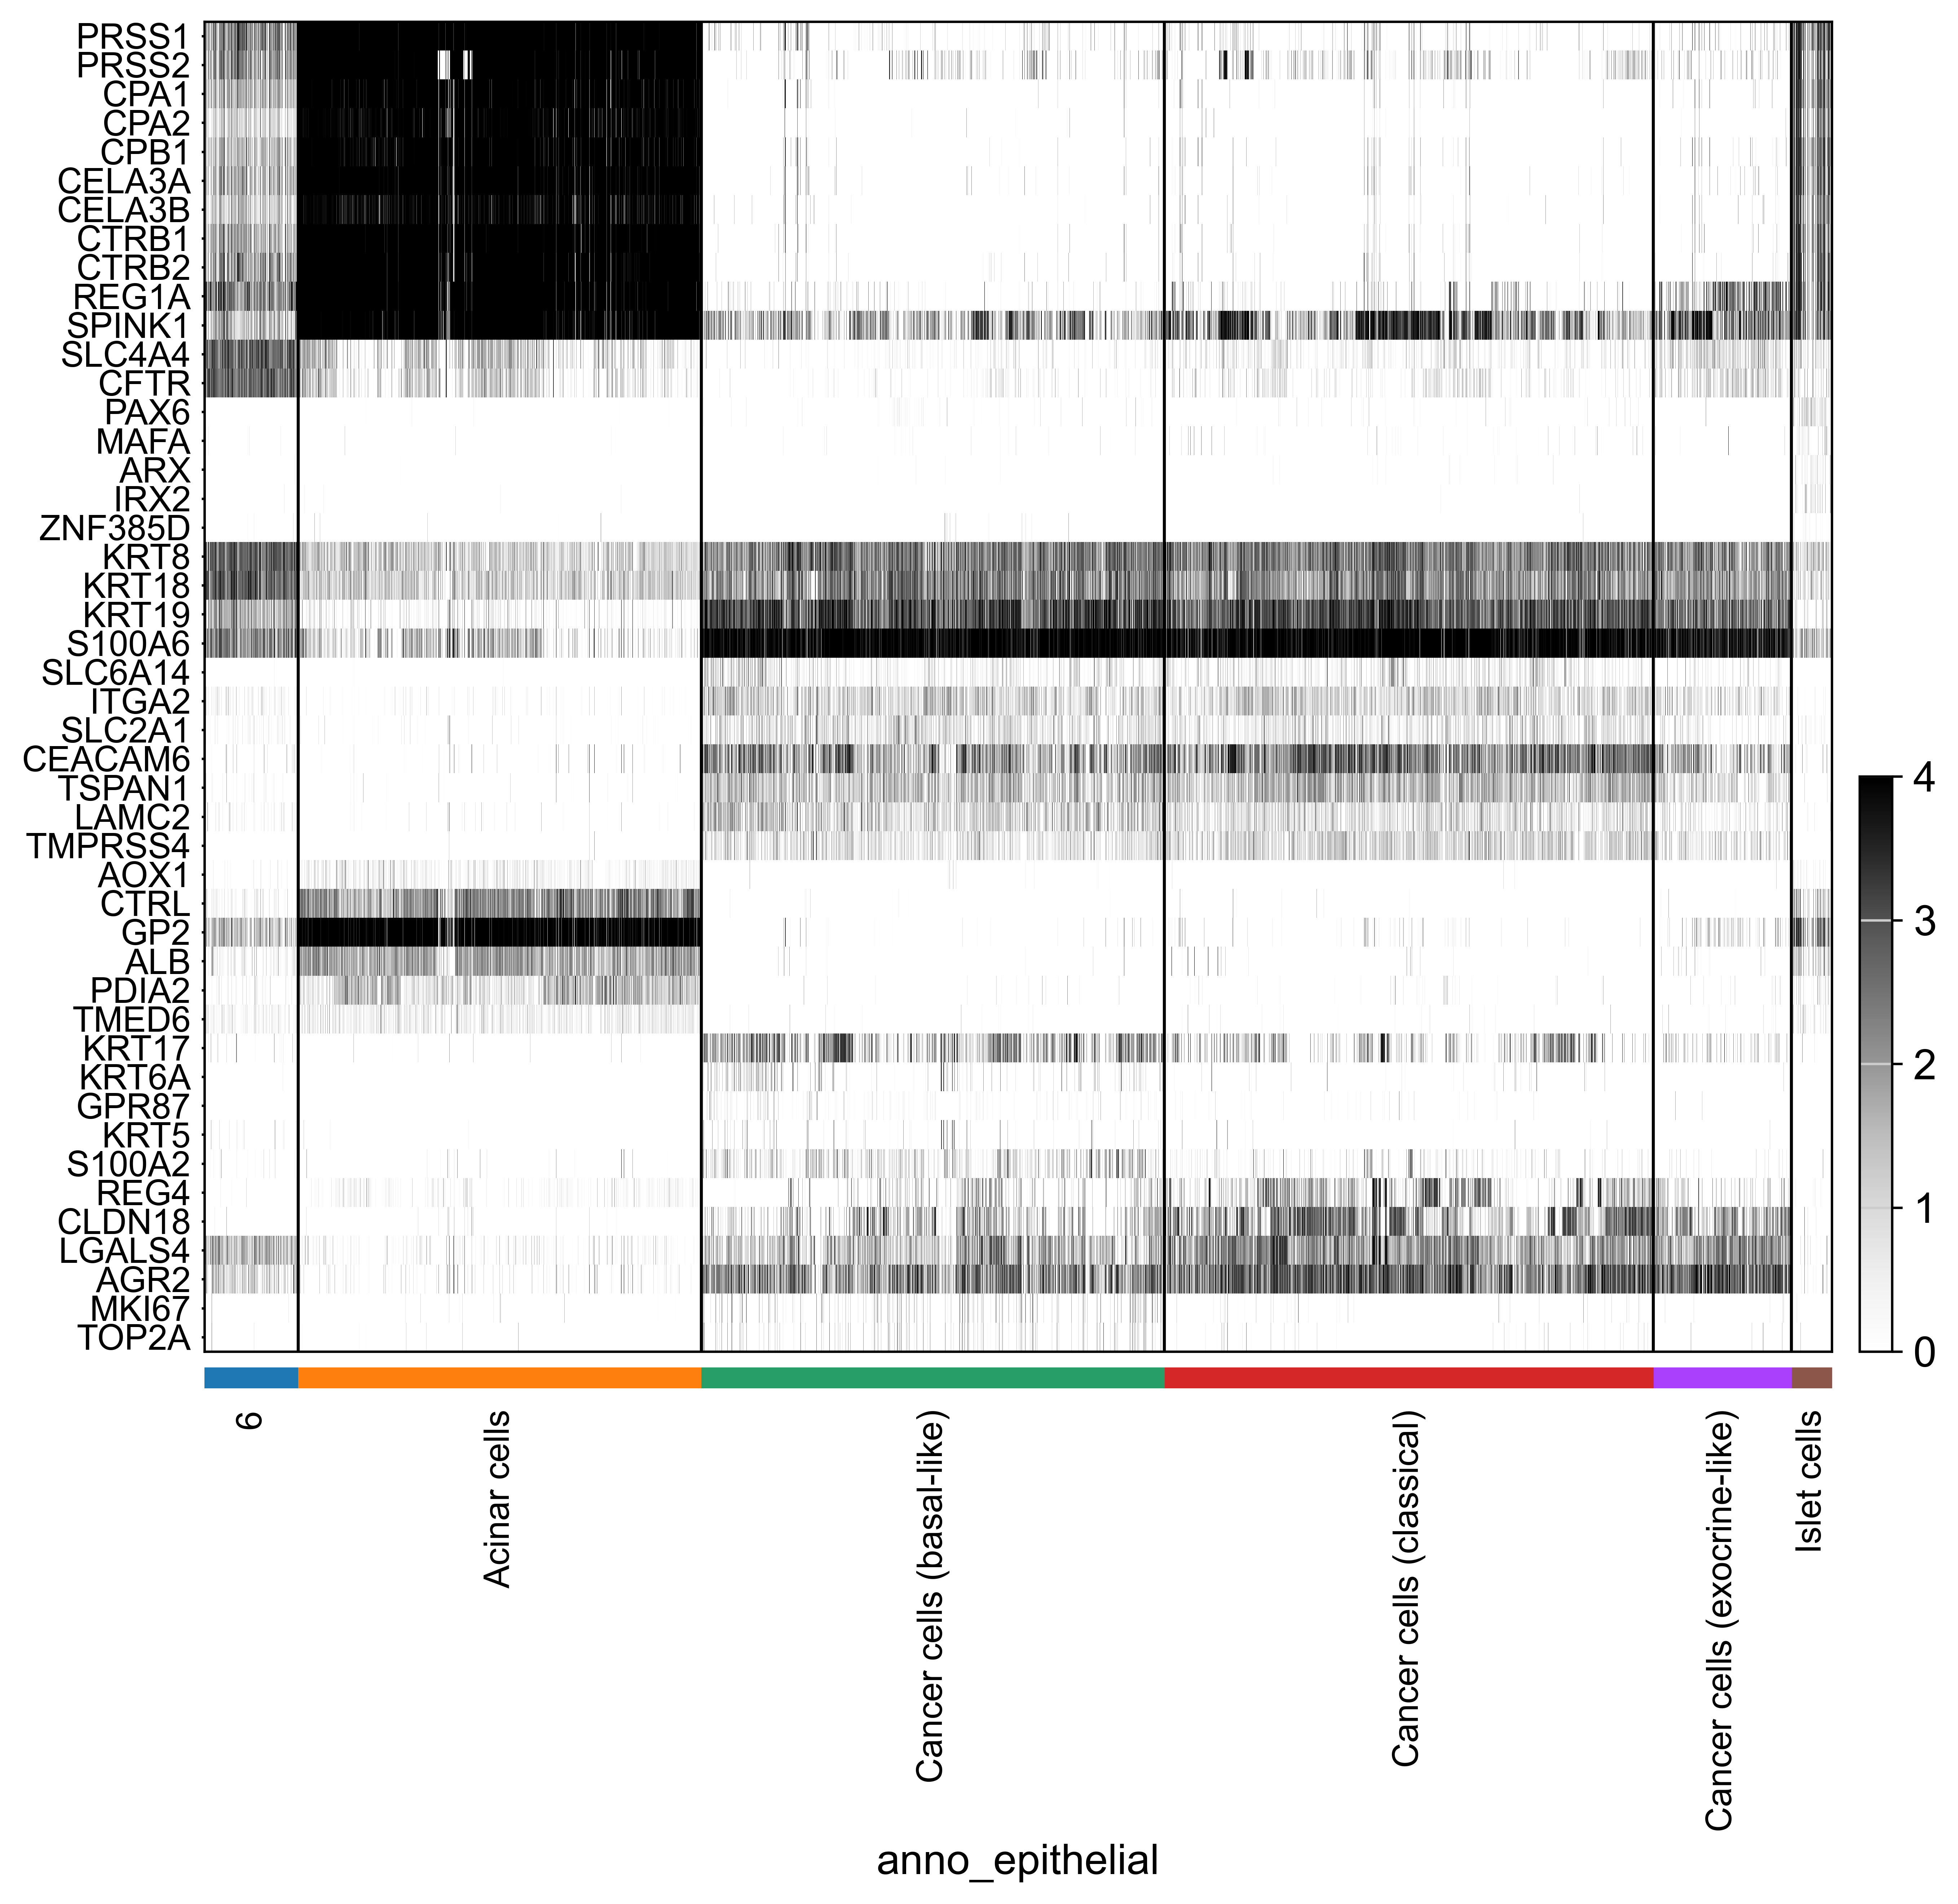

In [26]:
sc.pl.heatmap(
    adata_epithelial,
    groupby="anno_epithelial",
    var_names=[
        "PRSS1","PRSS2","CPA1","CPA2","CPB1","CELA3A","CELA3B","CTRB1","CTRB2","REG1A","SPINK1", #Acinar cells
        'SLC4A4', 'CFTR',    # Ductal cells
        'PAX6','MAFA','ARX','IRX2','ZNF385D', #Islet cells
        'KRT8', 'KRT18',
        "KRT19","S100A6",
        'SLC6A14',"ITGA2","SLC2A1","CEACAM6","TSPAN1","LAMC2","TMPRSS4", #cancer
        'AOX1',"CTRL","GP2","ALB","PDIA2","TMED6", #non cancer
        'KRT17','KRT6A','GPR87','KRT5','S100A2',#Cancer cells (basal-like)
        'REG4','CLDN18','LGALS4',"AGR2", #Cancer cells (classical)
        'MKI67','TOP2A',


               ], 
    swap_axes=True, 
    cmap='Greys'
    , vmax="4",
                              show_gene_labels=True

    )

In [ ]:
adm = adata_epithelial[adata_epithelial.obs['anno_epithelial'].isin(['6'])].copy()
sc.tl.pca(adm, n_comps=30)
sc.pp.neighbors(adm, n_neighbors=15, n_pcs=20)
sc.tl.umap(adm)
sc.tl.leiden(adm, resolution=0.3, key_added='adm_leiden') 

In [38]:
adm.obs['adm_leiden'] = adm.obs['adm_leiden'].astype(str)
cell_type = {
    '0': 'ADM',
    '1': 'Ductal cells',
    '2': 'Ductal cells',
    '3': 'Ductal cells',
    '4': 'ADM',
    '5': 'Ductal cells',
    '6': 'ADM',
    '7': 'ADM',
    '8': 'Ductal cells',
    '9': 'ADM',
    '10': 'ADM',
    '11': 'Ductal cells',
    '12': 'Ductal cells',

}
adm.obs['anno_epithelial'] = adm.obs['adm_leiden'].map(cell_type)
adata_anno = adm.obs['adm_leiden']

In [42]:
adm_annotations = adm.obs[['anno_epithelial']].copy()
adm_annotations = adm_annotations.rename(columns={'anno_epithelial': 'new_anno_epithelial'})

In [43]:
obs = adata_epithelial.obs.join(adm_annotations, how='left')
mask = obs['new_anno_epithelial'].notna()
obs['anno_epithelial'] = obs['anno_epithelial'].astype(object)
obs.loc[mask, 'anno_epithelial'] = obs.loc[mask, 'new_anno_epithelial'].astype(object)
obs = obs.drop(columns=['new_anno_epithelial'])
obs['anno_epithelial'] = pd.Categorical(obs['anno_epithelial'])
adata_epithelial.obs = obs

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:03:41)


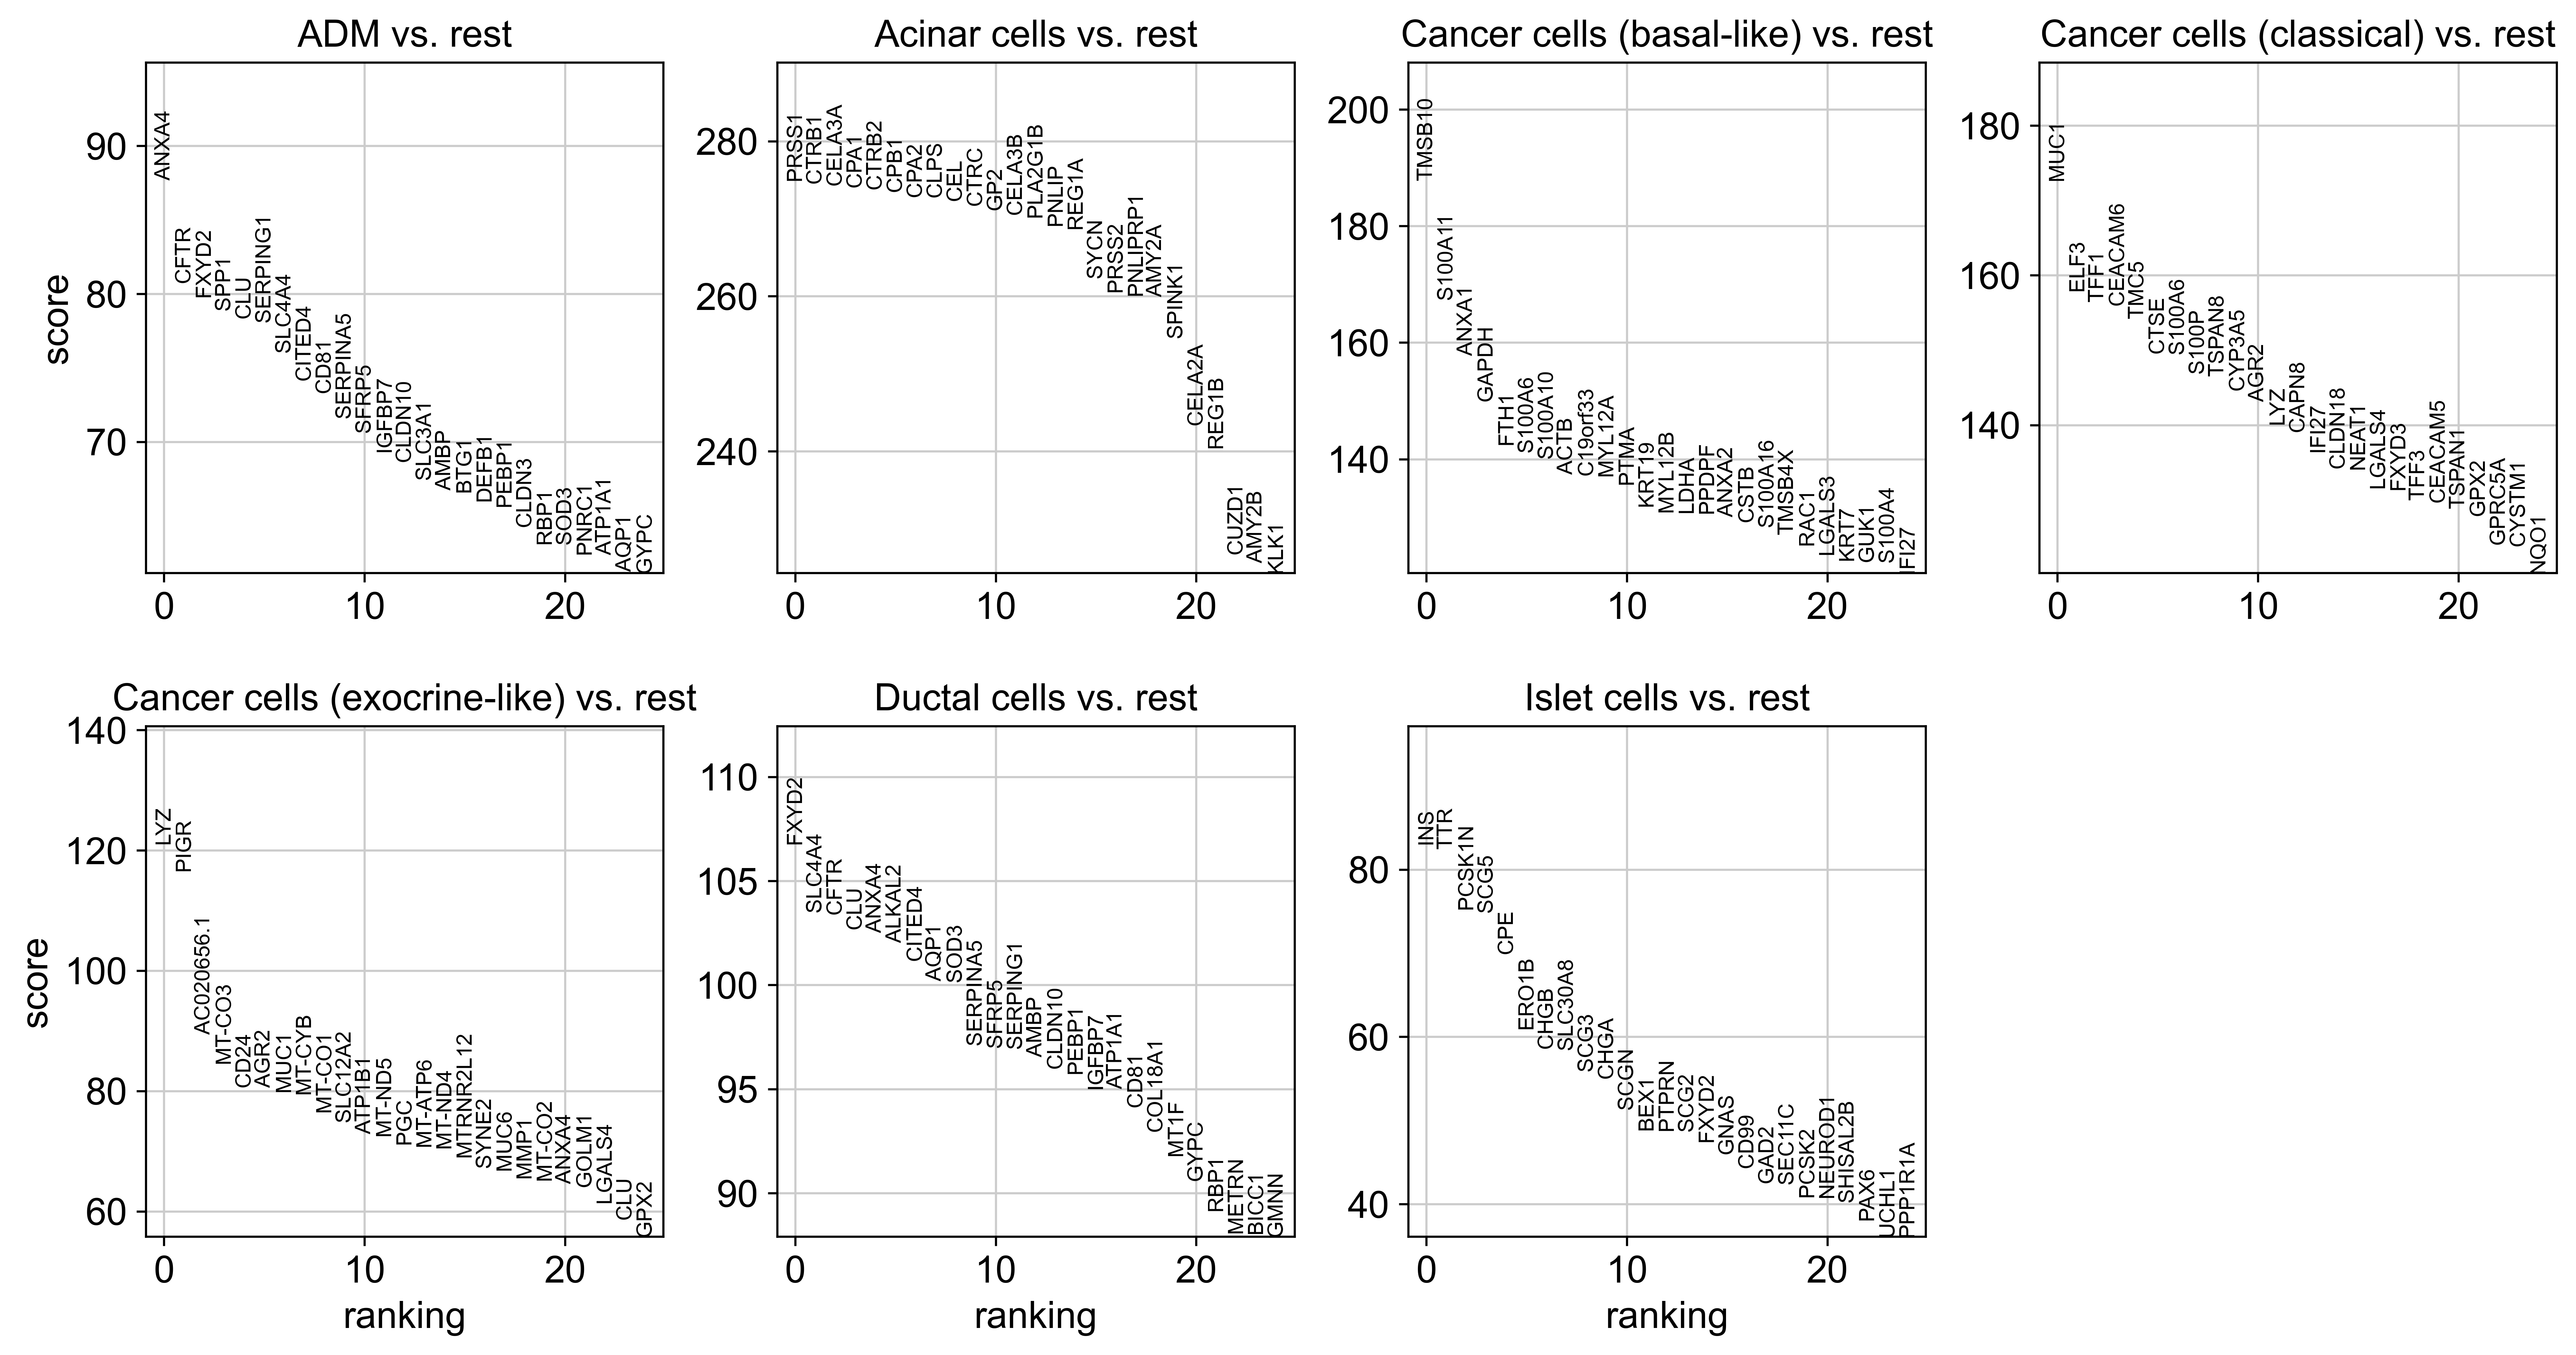

In [45]:
sc.tl.rank_genes_groups(adata_epithelial, 'anno_epithelial', method='wilcoxon')
sc.pl.rank_genes_groups(adata_epithelial, n_genes=25, sharey=False)

In [48]:
results = adata_epithelial.uns['rank_genes_groups']
out = np.array([[0,0,0,0,0]])
for group in results['names'].dtype.names:
    out = np.vstack((out, np.vstack((results['names'][group],
                                     results['scores'][group],
                                     results['pvals_adj'][group],
                                     results['logfoldchanges'][group],
                                     np.array([group]*len(results['names'][group])).astype('object'))).T))
    
markers = pd.DataFrame(out[1:], columns = ['Gene', 'scores', 'pval_adj', 'lfc', 'cluster'])
markers = markers[(markers.pval_adj < 0.05) & (abs(markers.lfc) > 1)]
markers.to_excel('../25-09-21_MSC027_CF_PDAC.atlas/results/250921.atlas/adata_epithelial_differentially_expressed_genes.xlsx')

In [ ]:
adata_epithelial.write('../yourpath/3_atlasSub_anno_epithelial.h5ad')